In [50]:
import pandas as pd
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller  # Import ADF test
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.pyplot as plt


# Define the file path
file_path = '/Users/Georgi/Dropbox/Data and AI/Applications/Group Project Datasets/Aggregated_data_20241019.parquet'

# Load the parquet file into a DataFrame
df = pd.read_parquet(file_path)
# Filter the DataFrame without changing the original df name
df = df[(df['item_family'].isin(['GROCERY I', 'POULTRY'])) & (df['week_number_cum'] >= 138)]




# Display the first few rows of the updated DataFrame
df.head()


,store_nbr,item_nbr,year,week_number_cum,unit_sales,onpromotion,holiday_local_count,holiday_regional_count,holiday_national_count,date,store_type,store_cluster,item_family,item_class,perishable,store_status,item_status
137,1,96995,2015,138,0.0,0,0,0,0,2015-08-17,D,13,GROCERY I,1093,0,0,1
138,1,96995,2015,139,0.0,0,0,0,0,2015-08-24,D,13,GROCERY I,1093,0,0,1
139,1,96995,2015,140,0.0,0,0,0,0,2015-08-31,D,13,GROCERY I,1093,0,0,1
140,1,96995,2015,141,0.0,0,0,0,0,2015-09-07,D,13,GROCERY I,1093,0,0,1
141,1,96995,2015,142,0.0,0,0,0,0,2015-09-14,D,13,GROCERY I,1093,0,0,1


/Users/Georgi/Documents/Group4B/venv_case_project/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


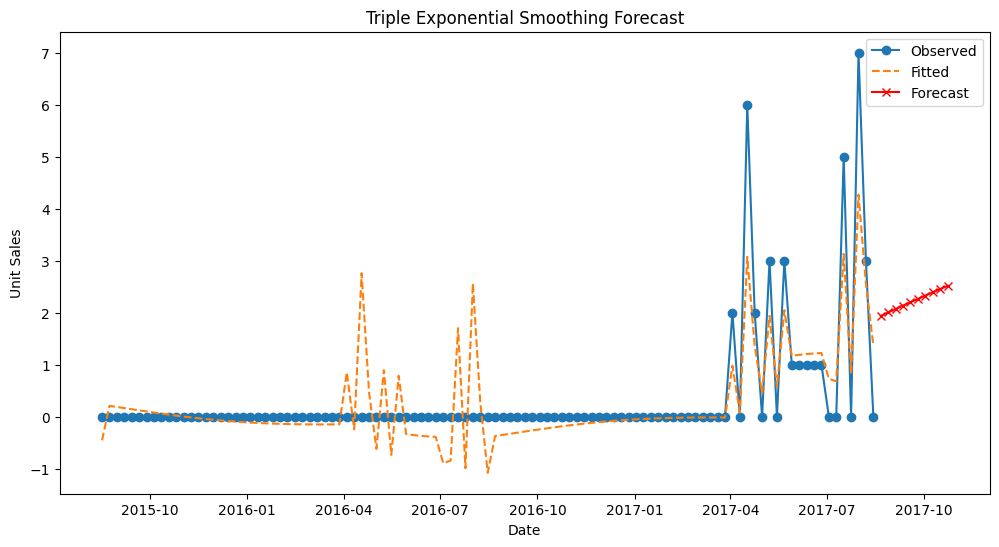

In [51]:
# Filter for specific store and item
store_nbr = 1
item_nbr = 96995
df_filtered = df[(df['store_nbr'] == store_nbr) & (df['item_nbr'] == item_nbr)]

# Set date as index
df_filtered.set_index('date', inplace=True)

# Ensure we are only using 'unit_sales' for the model
unit_sales = df_filtered['unit_sales']

# Check for sufficient data points for modeling
if len(unit_sales) < 2:
    raise ValueError("Not enough data points to run the model.")

# Run the Triple Exponential Smoothing model
model = ExponentialSmoothing(unit_sales, trend='add', seasonal='add', seasonal_periods=52)
fit_model = model.fit()

# Forecast the next periods (for example, 10 weeks)
forecast = fit_model.forecast(steps=10)

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(unit_sales, label='Observed', marker='o')
plt.plot(fit_model.fittedvalues, label='Fitted', linestyle='--')
plt.plot(forecast, label='Forecast', marker='x', color='red')
plt.title('Triple Exponential Smoothing Forecast')
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.legend()
plt.show()
